In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pickle
from nltk.tokenize import word_tokenize
import nltk

# Download the NLTK punkt tokenizer (if not already downloaded)
nltk.download('punkt')

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string for the file path
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
print("Tokenizing text data...")
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Step 2: Train a Word2Vec model
print("Training Word2Vec model...")
word2vec_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=1, workers=4)

# Step 3: Convert text data to numeric features using Word2Vec
print("Converting text data to numeric features...")
def text_to_avg_vector(tokens):
    vectors = [word2vec_model.wv[word] for word in tokens if word in word2vec_model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(word2vec_model.vector_size)

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]  # Target labels

# Step 4: Normalize features for Multinomial Naive Bayes
print("Normalizing feature vectors...")
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Step 5: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Initialize and train the Multinomial Naive Bayes model
print("Training Multinomial Naive Bayes model...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Step 7: Save the trained Multinomial Naive Bayes model
model_path = r"C:\Users\PC\Downloads\MultinomialNB_model.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(nb_model, f)
print(f"Trained Multinomial Naive Bayes model saved to {model_path}")

# Save the Word2Vec model
word2vec_path = r"C:\Users\PC\Downloads\Word2Vec_model.model"
word2vec_model.save(word2vec_path)
print(f"Word2Vec model saved to {word2vec_path}")

# Save the scaler
scaler_path = r"C:\Users\PC\Downloads\MinMaxScaler.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {scaler_path}")

# Step 8: Evaluate the Multinomial Naive Bayes model
y_pred_nb = nb_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='weighted')
recall = recall_score(y_test, y_pred_nb, average='weighted')
f1 = f1_score(y_test, y_pred_nb, average='weighted')

# Print metrics in the desired format
print(f"Multinomial Naive Bayes Accuracy: {accuracy * 100:.2f}%")
print(f"Multinomial Naive Bayes Precision: {precision * 100:.2f}%")
print(f"Multinomial Naive Bayes Recall: {recall * 100:.2f}%")
print(f"Multinomial Naive Bayes F1 Score: {f1 * 100:.2f}%")

# Print detailed classification report (optional)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_nb))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenizing text data...
Training Word2Vec model...
Converting text data to numeric features...
Normalizing feature vectors...
Training Multinomial Naive Bayes model...
Trained Multinomial Naive Bayes model saved to C:\Users\PC\Downloads\MultinomialNB_model.pkl
Word2Vec model saved to C:\Users\PC\Downloads\Word2Vec_model.model
Scaler saved to C:\Users\PC\Downloads\MinMaxScaler.pkl
Multinomial Naive Bayes Accuracy: 84.91%
Multinomial Naive Bayes Precision: 85.57%
Multinomial Naive Bayes Recall: 84.91%
Multinomial Naive Bayes F1 Score: 84.84%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.78      0.84     23238
           1       0.81      0.92      0.86     23171

    accuracy                           0.85     46409
   macro avg       0.86      0.85      0.85     46409
weighted avg       0.86      0.85      0.85     46409



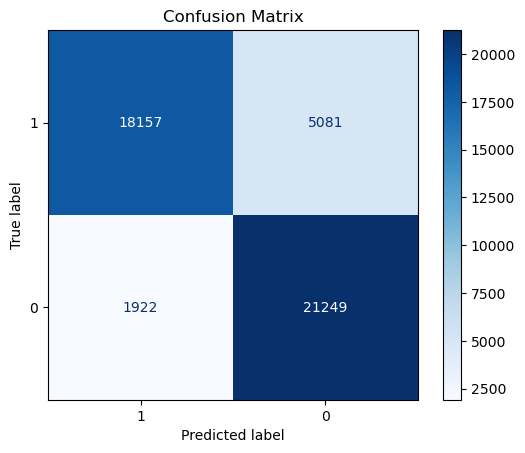

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)

# Step 2: Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


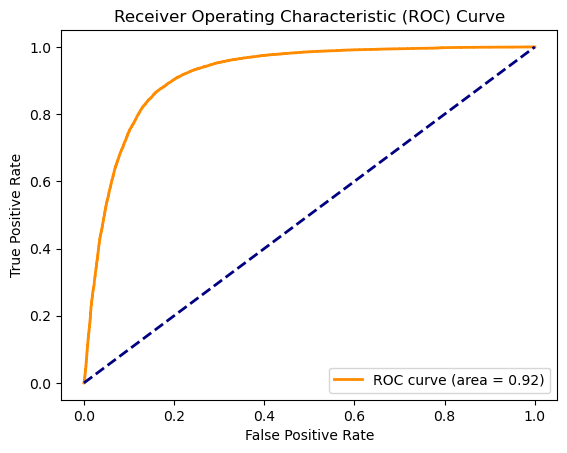

In [3]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Step 1: Binarize the labels for multi-class ROC (if necessary)
classes = y.unique()  # Unique classes in the target variable
n_classes = len(classes)

if n_classes > 2:
    y_test_bin = label_binarize(y_test, classes=classes)
    y_pred_prob = nb_model.predict_proba(X_test)  # Get probability predictions
else:
    y_test_bin = y_test
    y_pred_prob = nb_model.predict_proba(X_test)[:, 1]  # Probability for the positive class

# Step 2: Plot ROC Curve
if n_classes == 2:
    # Binary classification
    fpr, tpr, _ = roc_curve(y_test_bin, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()
else:
    # Multi-class classification
    plt.figure()
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {classes[i]} (area = {roc_auc:.2f})")
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve - Multi-Class")
    plt.legend(loc="lower right")
    plt.show()


Training Multinomial Naive Bayes model...
Multinomial Naive Bayes MAE: 0.1509, MSE: 0.1509, RMSE: 0.3885


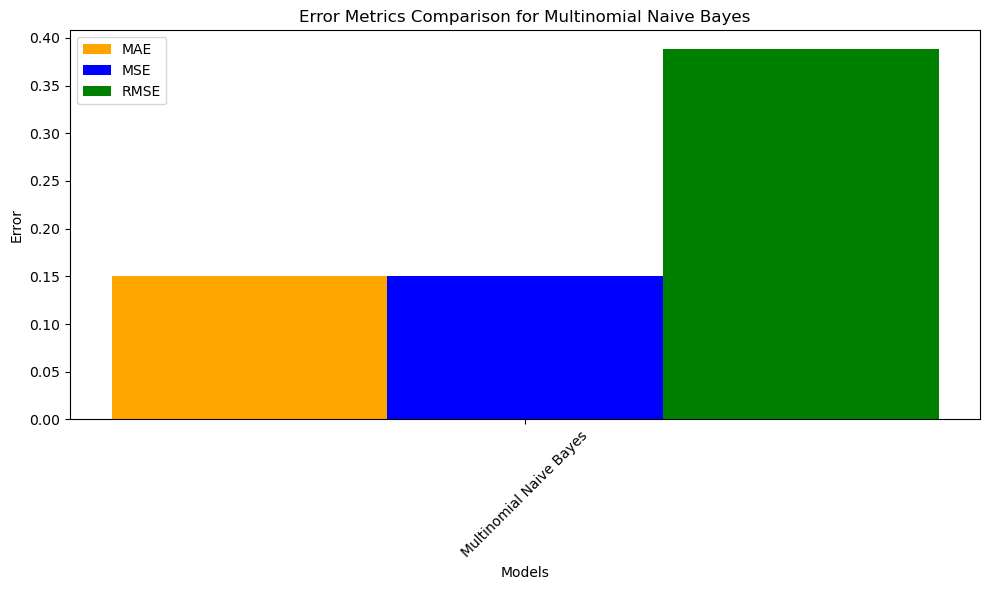

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB

# Dictionary to store error metrics
error_metrics = {}

# Initialize and train the Multinomial Naive Bayes model
print("Training Multinomial Naive Bayes model...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_nb = nb_model.predict(X_test)

# Calculate error metrics
mae_nb = mean_absolute_error(y_test, y_pred_nb)
mse_nb = mean_squared_error(y_test, y_pred_nb)
rmse_nb = np.sqrt(mse_nb)

# Store error metrics
error_metrics["Multinomial Naive Bayes"] = {"MAE": mae_nb, "MSE": mse_nb, "RMSE": rmse_nb}

# Print metrics
print(f"Multinomial Naive Bayes MAE: {mae_nb:.4f}, MSE: {mse_nb:.4f}, RMSE: {rmse_nb:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison for Multinomial Naive Bayes')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


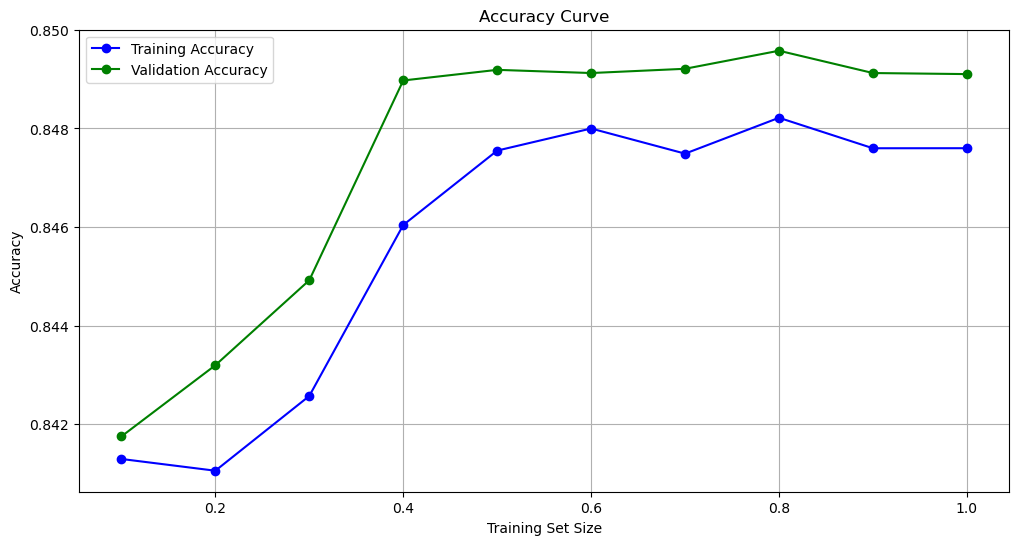

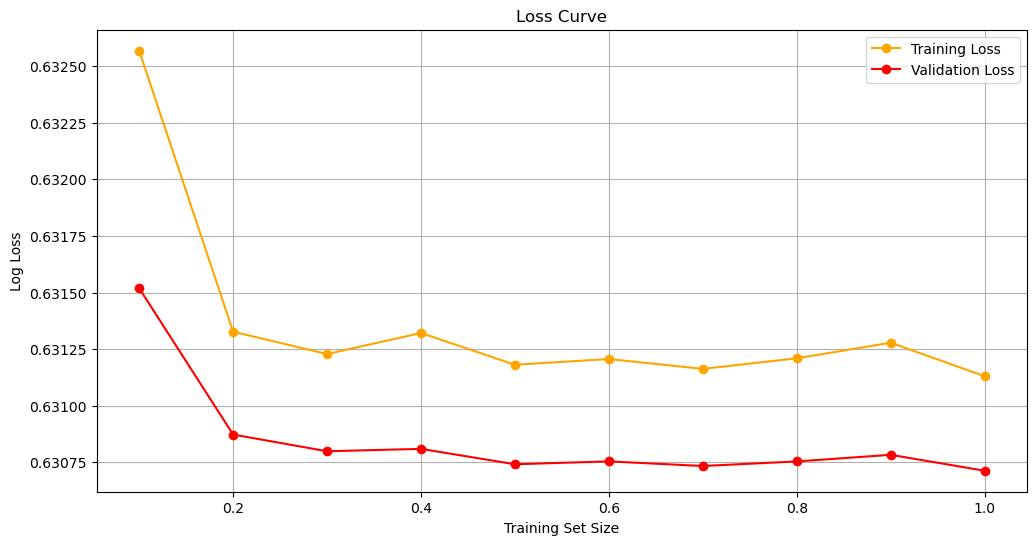

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score
from sklearn.naive_bayes import MultinomialNB

# Initialize Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Arrays to store accuracy and loss
train_sizes = np.linspace(0.1, 1.0, 10)  # Progressively larger portions of the training data
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

# Loop through different training data sizes
for size in train_sizes:
    # Use a portion of the training data
    subset_size = int(size * len(X_train))
    X_train_subset = X_train[:subset_size]
    y_train_subset = y_train[:subset_size]
    
    # Train the model on the subset
    nb_model.fit(X_train_subset, y_train_subset)
    
    # Predict on the training subset and validation set
    y_train_pred = nb_model.predict(X_train_subset)
    y_val_pred = nb_model.predict(X_test)
    
    # Predict probabilities for loss calculation
    y_train_proba = nb_model.predict_proba(X_train_subset)
    y_val_proba = nb_model.predict_proba(X_test)
    
    # Calculate accuracy
    train_accuracies.append(accuracy_score(y_train_subset, y_train_pred))
    val_accuracies.append(accuracy_score(y_test, y_val_pred))
    
    # Calculate log loss
    train_losses.append(log_loss(y_train_subset, y_train_proba))
    val_losses.append(log_loss(y_test, y_val_proba))

# Plot Accuracy Curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(train_sizes, val_accuracies, label='Validation Accuracy', marker='o', color='green')
plt.title('Accuracy Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid()
plt.show()

# Plot Loss Curve
plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_losses, label='Training Loss', marker='o', color='orange')
plt.plot(train_sizes, val_losses, label='Validation Loss', marker='o', color='red')
plt.title('Loss Curve')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.legend(loc='best')
plt.grid()
plt.show()
